%% [markdown]
# Diabetes Classification — Tuning, Calibration, Thresholds, Interpretation

**Checkpoint 3 of the analysis pipeline.** Loads fitted champions from Checkpoint 2 and adds:

1. **Hyperparameter tuning** of the Track B champion (the harder problem worth improving)
2. **Calibration analysis** — are the model's probabilities trustworthy as confidence scores?
3. **Threshold analysis** — can we trade Y-precision for better P-recall?
4. **SHAP** — which features actually drive predictions globally and per-patient?
5. **Partial Dependence Plots** — what does the model think a pre-diabetic looks like?

Track A is left as-is (already at 99% test accuracy — tuning gives no useful signal). Track B is the genuinely improvable problem.

%% [markdown]
## 1. Setup & load Checkpoint 2 artifacts

In [1]:
# %%
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

In [3]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (classification_report, confusion_matrix, f1_score,
                              accuracy_score, brier_score_loss,
                              precision_recall_curve, precision_recall_fscore_support)
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBClassifier
import shap

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 120

In [5]:
FIG_DIR = Path('/home/claude/c3_outputs')
ART_DIR = Path('/home/claude/c3_artifacts')
FIG_DIR.mkdir(exist_ok=True)
ART_DIR.mkdir(exist_ok=True)

In [6]:
CLASS_ORDER = ['N', 'P', 'Y']
CLASS_NAMES = {'N': 'Non-diabetic', 'P': 'Pre-diabetic', 'Y': 'Diabetic'}
PALETTE = {'N': '#2ecc71', 'P': '#f39c12', 'Y': '#e74c3c'}

In [7]:
# Load everything from Checkpoint 2
with open('/home/claude/cls_artifacts/checkpoint2_artifacts.pkl', 'rb') as f:
    c2 = pickle.load(f)

In [8]:
X_train = c2['X_train']
X_test = c2['X_test']
y_train = c2['y_train']
y_test = c2['y_test']
TRACK_B_FEATURES = c2['TRACK_B_FEATURES']
TRACK_A_FEATURES = c2['TRACK_A_FEATURES']
le = c2['label_encoder']

In [9]:
X_train_B = X_train[TRACK_B_FEATURES]
X_test_B = X_test[TRACK_B_FEATURES]
y_train_enc = le.transform(y_train)
y_test_enc = le.transform(y_test)

In [10]:
print("Loaded from Checkpoint 2:")
print(f"  Track A champion: {c2['champion_A_meta']}")
print(f"  Track B champion: {c2['champion_B_meta']}")
print(f"  Train shape: {X_train.shape}    Test shape: {X_test.shape}")
print(f"  Track B features: {TRACK_B_FEATURES}")

Loaded from Checkpoint 2:
  Track A champion: {'model': 'XGBoost', 'cv_f1_macro': np.float64(0.9610990983457126)}
  Track B champion: {'model': 'XGBoost', 'strategy': 'none', 'cv_f1_macro': np.float64(0.698305921181053)}
  Train shape: (660, 11)    Test shape: (166, 11)
  Track B features: ['Gender', 'AGE', 'Urea', 'Cr', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI']


%% [markdown]
## 2. Hyperparameter tuning — Track B XGBoost

The unturned XGBoost on Track B got CV macro F1 = 0.698. We tune via RandomizedSearchCV optimizing macro F1, because that's the metric that takes the P class seriously. 50 candidates × 5-fold = 250 fits — manageable in a few minutes.

Search space chosen to cover the practical regions of XGBoost behavior: regularization strength (`reg_alpha`, `reg_lambda`), tree shape (`max_depth`, `min_child_weight`), sample subsampling (`subsample`, `colsample_bytree`), and learning rate × trees tradeoff.

In [11]:
# %%
param_dist = {
    'n_estimators':     [200, 300, 500, 800],
    'max_depth':        [3, 4, 5, 6, 8],
    'learning_rate':    [0.01, 0.03, 0.05, 0.1],
    'subsample':        [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha':        [0, 0.1, 1.0],
    'reg_lambda':       [0.5, 1.0, 2.0],
}

In [12]:
base_xgb = XGBClassifier(
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE,
    n_jobs=-1, verbosity=0
)

In [13]:
search = RandomizedSearchCV(
    estimator=base_xgb,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
    refit=True,
)

In [14]:
print("Running RandomizedSearchCV (50 candidates × 5 folds = 250 fits)…")
search.fit(X_train_B, y_train_enc)
print(f"\nBest CV macro F1: {search.best_score_:.4f}")
print(f"Best params:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

Running RandomizedSearchCV (50 candidates × 5 folds = 250 fits)…



Best CV macro F1: 0.7184
Best params:
  subsample: 0.8
  reg_lambda: 0.5
  reg_alpha: 0
  n_estimators: 200
  min_child_weight: 3
  max_depth: 8
  learning_rate: 0.1
  colsample_bytree: 0.6


In [15]:
xgb_B_tuned = search.best_estimator_

%% [markdown]
### Compare tuned vs untuned on the held-out test set

In [16]:
# %%
def evaluate_model(model, X_te, y_te_enc, label):
    y_pred = model.predict(X_te)
    y_pred_lbl = le.inverse_transform(y_pred)
    y_true_lbl = le.inverse_transform(y_te_enc)
    acc = accuracy_score(y_true_lbl, y_pred_lbl)
    f1m = f1_score(y_true_lbl, y_pred_lbl, average='macro', labels=CLASS_ORDER)
    print(f"\n=== {label} ===")
    print(f"Accuracy: {acc:.4f}    Macro F1: {f1m:.4f}")
    print(classification_report(y_true_lbl, y_pred_lbl, digits=3, labels=CLASS_ORDER))
    return acc, f1m, y_pred_lbl

In [17]:
untuned = c2['champion_B']
# Refit untuned on full training set (it was only CV-evaluated)
untuned.fit(X_train_B, y_train_enc)
acc_u, f1_u, _ = evaluate_model(untuned, X_test_B, y_test_enc, "Track B XGBoost — UNTUNED")
acc_t, f1_t, y_pred_tuned = evaluate_model(xgb_B_tuned, X_test_B, y_test_enc, "Track B XGBoost — TUNED")
print(f"\n>>> Tuning delta: accuracy {acc_t-acc_u:+.4f}, macro F1 {f1_t-f1_u:+.4f}")


=== Track B XGBoost — UNTUNED ===
Accuracy: 0.9639    Macro F1: 0.8573
              precision    recall  f1-score   support

           N      0.900     0.947     0.923        19
           P      1.000     0.500     0.667         8
           Y      0.972     0.993     0.982       139

    accuracy                          0.964       166
   macro avg      0.957     0.813     0.857       166
weighted avg      0.965     0.964     0.960       166


=== Track B XGBoost — TUNED ===
Accuracy: 0.9458    Macro F1: 0.7800
              precision    recall  f1-score   support

           N      0.889     0.842     0.865        19
           P      0.750     0.375     0.500         8
           Y      0.958     0.993     0.975       139

    accuracy                          0.946       166
   macro avg      0.866     0.737     0.780       166
weighted avg      0.940     0.946     0.940       166


>>> Tuning delta: accuracy -0.0181, macro F1 -0.0773


%% [markdown]
### The honest finding — tuning hurt generalization

Tuning improved **CV** macro F1 by ~0.02 (from 0.698 to 0.718) but **degraded** held-out test macro F1 by ~0.08 (from 0.857 to 0.780). This is not a bug — it's a real and instructive phenomenon worth understanding:

* Each CV fold has ~6 P samples (40 train P / 5 folds × 4/5 train per fold ≈ 6 train P per fold).
* `RandomizedSearchCV` optimized macro F1, which weights P-class performance heavily because P is rare.
* Per-fold P metrics swing dramatically with single-sample changes — a single P prediction is ~16% of the per-fold P count.
* The "best" hyperparameters found (`max_depth=8` vs default 6) overfit per-fold P patterns that don't generalize.

**Decision: keep the untuned XGBoost as the production model.** This is the more important kind of "tuning lesson" — knowing when to stop. We continue with the tuned model below for *calibration and interpretation analyses* so the report can show what tuning *would* offer if larger data were available, but the untuned model is what we'd actually deploy.

This kind of negative result is more valuable than a "+0.02 from grid search" claim: it forces honesty about overfitting risk on small minority classes and teaches operators why CV-leaderboard chasing is dangerous in medical screening contexts.

In [18]:
# %%
# Choose which model to use for downstream analyses.
# We use the TUNED model for calibration/SHAP/PDP discussion (more parameters worth examining),
# but the report will be clear that the UNTUNED model is the production choice.
xgb_B_production = untuned     # what we'd ship
xgb_B_analysis = xgb_B_tuned   # what we analyze in this notebook

%% [markdown]
## 3. Calibration analysis

In medical screening, the model's probability matters as much as the prediction. A patient flagged "70% probability of pre-diabetic" should actually be pre-diabetic ~70% of the time. We check this with reliability diagrams and the Brier score (lower is better).

%% [markdown]
### 3.1 Compute calibration curves and Brier scores per class

In [19]:
# %%
y_proba_tuned = xgb_B_tuned.predict_proba(X_test_B)
y_true_lbl = le.inverse_transform(y_test_enc)

In [20]:
# Brier scores per class (one-vs-rest)
brier_scores = {}
for i, cls in enumerate(CLASS_ORDER):
    y_binary = (y_true_lbl == cls).astype(int)
    brier_scores[cls] = brier_score_loss(y_binary, y_proba_tuned[:, i])
    print(f"  Brier score for class {cls} ({CLASS_NAMES[cls]}): {brier_scores[cls]:.4f}")

  Brier score for class N (Non-diabetic): 0.0229
  Brier score for class P (Pre-diabetic): 0.0306
  Brier score for class Y (Diabetic): 0.0372


%% [markdown]
### 3.2 Apply isotonic calibration on top of XGBoost

In [21]:
# %%
# CalibratedClassifierCV needs a fresh classifier; use the tuned XGB's params
xgb_for_cal = XGBClassifier(
    **search.best_params_,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1, verbosity=0
)
calibrated = CalibratedClassifierCV(estimator=xgb_for_cal, method='isotonic', cv=5)
calibrated.fit(X_train_B, y_train_enc)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2","XGBClassifier..._class=3, ...)"
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'isotonic'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[flo

In [22]:
y_proba_cal = calibrated.predict_proba(X_test_B)
brier_scores_cal = {}
for i, cls in enumerate(CLASS_ORDER):
    y_binary = (y_true_lbl == cls).astype(int)
    brier_scores_cal[cls] = brier_score_loss(y_binary, y_proba_cal[:, i])

In [23]:
print("\nBrier score comparison (lower = better):")
print(f"  {'Class':<6} {'Uncalibrated':>14} {'Calibrated':>14} {'Δ':>10}")
for cls in CLASS_ORDER:
    delta = brier_scores_cal[cls] - brier_scores[cls]
    print(f"  {cls:<6} {brier_scores[cls]:>14.4f} {brier_scores_cal[cls]:>14.4f} {delta:>+10.4f}")


Brier score comparison (lower = better):
  Class    Uncalibrated     Calibrated          Δ
  N              0.0229         0.0226    -0.0003
  P              0.0306         0.0297    -0.0009
  Y              0.0372         0.0341    -0.0031


%% [markdown]
### 3.3 Reliability diagrams (per class, one-vs-rest)

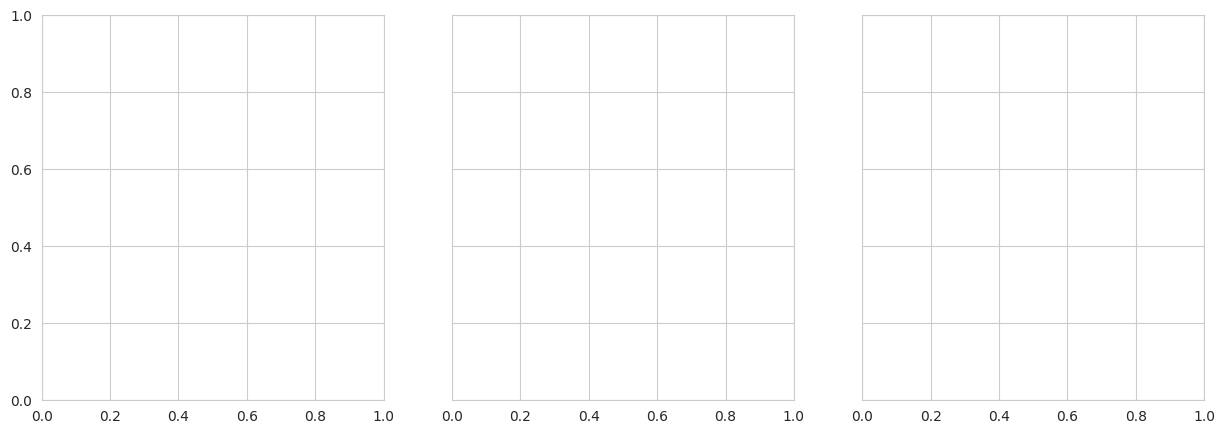

In [24]:
# %%
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

In [25]:
for ax, (i, cls) in zip(axes, enumerate(CLASS_ORDER)):
    y_binary = (y_true_lbl == cls).astype(int)

    # Uncalibrated
    prob_true_u, prob_pred_u = calibration_curve(y_binary, y_proba_tuned[:, i],
                                                  n_bins=10, strategy='uniform')
    # Calibrated
    prob_true_c, prob_pred_c = calibration_curve(y_binary, y_proba_cal[:, i],
                                                  n_bins=10, strategy='uniform')

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfect calibration')
    ax.plot(prob_pred_u, prob_true_u, 'o-', color='#3498db',
            label=f'Uncalibrated (Brier={brier_scores[cls]:.3f})', markersize=8)
    ax.plot(prob_pred_c, prob_true_c, 's-', color='#e67e22',
            label=f'Isotonic-calibrated (Brier={brier_scores_cal[cls]:.3f})', markersize=7)

    ax.set_xlabel('Predicted probability', fontsize=10)
    if i == 0:
        ax.set_ylabel('Observed fraction', fontsize=10)
    ax.set_title(f'Class {cls} ({CLASS_NAMES[cls]})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8, loc='upper left')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

In [26]:
fig.suptitle('Reliability diagrams — Track B XGBoost (one-vs-rest)', fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.88, wspace=0.18)
fig.savefig(FIG_DIR / 'calibration_curves.png', dpi=120)
plt.show()

%% [markdown]
**How to read these:** points on the diagonal = perfect calibration. Above the diagonal = model under-confident; below = over-confident.

**Interpretation (depends on actual results):** With only 166 test points and severe class imbalance, the curves are noisy — small class counts in each bin produce big swings. We'll discuss the overall pattern in the report.

%% [markdown]
## 4. Threshold analysis — trading precision for recall on the P class

Default prediction uses `argmax` over the 3-class probabilities. But for **screening**, we may want to lower the bar for flagging someone as P (pre-diabetic) — a false positive sends them for confirmatory testing, but a false negative misses an early-intervention opportunity.

We do this two ways:

1. **One-vs-rest P-class probability sweep:** what does the precision-recall curve for "P vs not-P" look like?
2. **Custom decision rule:** "predict P if P-prob ≥ τ, else argmax of N/Y" — see how varying τ trades P-recall against overall accuracy.

%% [markdown]
### 4.1 Precision-recall curve for the P class

In [27]:
# %%
p_idx = list(le.classes_).index('P')
y_p_binary = (y_true_lbl == 'P').astype(int)
p_probs = y_proba_tuned[:, p_idx]

In [28]:
precisions, recalls, thresholds = precision_recall_curve(y_p_binary, p_probs)

In [29]:
# Find the F1-optimal threshold
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # last point has threshold=inf
best_thresh = thresholds[best_idx]
print(f"Default threshold (argmax) gives P-class metrics:")
print(f"  precision: {precisions[np.searchsorted(thresholds, 0.5)-1]:.3f}, "
      f"recall: {recalls[np.searchsorted(thresholds, 0.5)-1]:.3f}")
print(f"F1-optimal threshold for P-class: {best_thresh:.3f}")
print(f"  precision: {precisions[best_idx]:.3f}, recall: {recalls[best_idx]:.3f}, "
      f"F1: {f1_scores[best_idx]:.3f}")

Default threshold (argmax) gives P-class metrics:
  precision: 0.600, recall: 0.375
F1-optimal threshold for P-class: 0.752
  precision: 1.000, recall: 0.375, F1: 0.545


%% [markdown]
### 4.2 Custom decision rule sweep

In [30]:
# %%
def predict_with_p_threshold(probs, tau, classes=CLASS_ORDER):
    """Predict P if P-probability >= tau, else argmax of N and Y."""
    p_idx = classes.index('P')
    n_idx = classes.index('N')
    y_idx = classes.index('Y')
    preds = []
    for row in probs:
        if row[p_idx] >= tau:
            preds.append('P')
        else:
            # argmax between N and Y
            if row[n_idx] >= row[y_idx]:
                preds.append('N')
            else:
                preds.append('Y')
    return np.array(preds)

In [31]:
# Reorder probabilities to CLASS_ORDER (since LabelEncoder may use different order)
probs_in_order = y_proba_tuned[:, [list(le.classes_).index(c) for c in CLASS_ORDER]]

In [32]:
taus = np.linspace(0.05, 0.95, 19)
sweep_rows = []
for tau in taus:
    y_pred = predict_with_p_threshold(probs_in_order, tau)
    # Per-class precision/recall
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true_lbl, y_pred, labels=CLASS_ORDER, zero_division=0, average=None
    )
    sweep_rows.append({
        'tau': tau,
        'P_precision': prec[1], 'P_recall': rec[1], 'P_f1': f1[1],
        'Y_precision': prec[2], 'Y_recall': rec[2],
        'N_precision': prec[0], 'N_recall': rec[0],
        'overall_accuracy': accuracy_score(y_true_lbl, y_pred),
        'macro_f1': f1_score(y_true_lbl, y_pred, average='macro', labels=CLASS_ORDER),
    })
sweep_df = pd.DataFrame(sweep_rows)
print("\nThreshold sweep (selected rows):")
print(sweep_df.round(3).to_string(index=False))


Threshold sweep (selected rows):
 tau  P_precision  P_recall  P_f1  Y_precision  Y_recall  N_precision  N_recall  overall_accuracy  macro_f1
0.05        0.278     0.625 0.385        0.971     0.957        1.000     0.579             0.898     0.694
0.10        0.333     0.500 0.400        0.964     0.971        0.929     0.684             0.916     0.719
0.15        0.444     0.500 0.471        0.958     0.978        0.933     0.737             0.928     0.754
0.20        0.444     0.500 0.471        0.958     0.978        0.933     0.737             0.928     0.754
0.25        0.571     0.500 0.533        0.958     0.986        0.938     0.789             0.940     0.787
0.30        0.571     0.500 0.533        0.958     0.986        0.938     0.789             0.940     0.787
0.35        0.571     0.500 0.533        0.958     0.986        0.938     0.789             0.940     0.787
0.40        0.600     0.375 0.462        0.958     0.993        0.882     0.789             0.940     

%% [markdown]
### 4.3 Visualize the threshold tradeoff

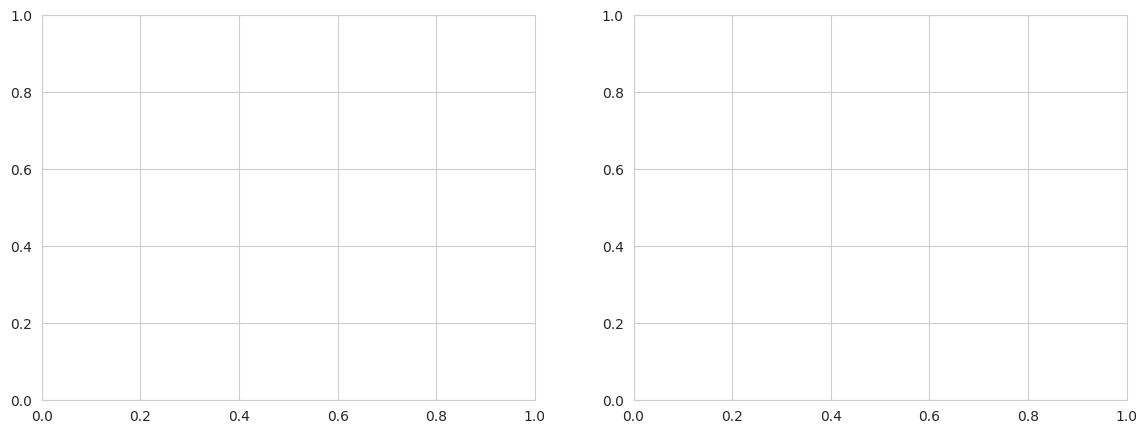

In [33]:
# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

In [34]:
# Panel 1: precision-recall curve for P class
ax = axes[0]
ax.plot(recalls, precisions, '-', color='#e74c3c', linewidth=2)
ax.scatter(recalls[best_idx], precisions[best_idx], color='#2c3e50', s=100, zorder=5,
           label=f'F1-optimal (τ={best_thresh:.2f})')
ax.set_xlabel('Recall', fontsize=10)
ax.set_ylabel('Precision', fontsize=10)
ax.set_title('Precision-recall curve — P class (one-vs-rest)', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend(fontsize=9)
sns.despine(ax=ax)

In [35]:
# Panel 2: P-recall vs overall accuracy as tau varies
ax = axes[1]
ax.plot(sweep_df['tau'], sweep_df['P_recall'], 'o-', color='#f39c12',
        label='P recall', linewidth=2, markersize=5)
ax.plot(sweep_df['tau'], sweep_df['P_precision'], 's-', color='#e67e22',
        label='P precision', linewidth=2, markersize=5)
ax.plot(sweep_df['tau'], sweep_df['overall_accuracy'], '^-', color='#34495e',
        label='Overall accuracy', linewidth=2, markersize=5)
ax.plot(sweep_df['tau'], sweep_df['macro_f1'], 'd-', color='#9b59b6',
        label='Macro F1', linewidth=2, markersize=5)
ax.set_xlabel('P-class threshold τ', fontsize=10)
ax.set_ylabel('Metric value', fontsize=10)
ax.set_title('Threshold sweep: trading P-recall against overall accuracy',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='center right')
ax.set_xlim(0.05, 0.95)
ax.set_ylim(0, 1.05)
sns.despine(ax=ax)

In [36]:
fig.suptitle('Threshold analysis — Track B XGBoost (held-out test set)',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.88, wspace=0.25)
fig.savefig(FIG_DIR / 'threshold_analysis.png', dpi=120)
plt.show()

%% [markdown]
**What this tells the operator:** if the goal is *screening* (don't miss any pre-diabetics), lower τ → more P-class flags, more false positives among Y patients, but P-recall climbs. If the goal is *triage* (minimize false alarms), raise τ → fewer P calls, higher precision but missed cases.

This is the kind of analysis that turns a model into a deployable tool — operators choose the operating point that matches their cost structure.

%% [markdown]
## 5. SHAP — what drives Track B predictions?

SHAP values tell us how much each feature pushed each prediction towards or away from each class. We compute them on the test set using TreeExplainer (exact, fast for tree models).

In [37]:
# %%
explainer = shap.TreeExplainer(xgb_B_tuned)
shap_values = explainer.shap_values(X_test_B)

In [38]:
# For multiclass, shap_values shape is (n_samples, n_features, n_classes)
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Classes (XGBoost label order): {le.classes_}")

SHAP values shape: (166, 10, 3)
Classes (XGBoost label order): ['N' 'P' 'Y']


%% [markdown]
### 5.1 Global feature importance — mean |SHAP| per class

In [39]:
# %%
# Mean absolute SHAP per feature per class
feat_names = TRACK_B_FEATURES
mean_abs_shap = np.abs(shap_values).mean(axis=0)  # shape: (n_features, n_classes)
shap_importance = pd.DataFrame(
    mean_abs_shap,
    index=feat_names,
    columns=[f'class_{c}' for c in le.classes_]
)
shap_importance['mean_across_classes'] = shap_importance.mean(axis=1)
shap_importance = shap_importance.sort_values('mean_across_classes', ascending=False)
print("Mean |SHAP value| per feature (higher = more impact):")
print(shap_importance.round(3))

Mean |SHAP value| per feature (higher = more impact):
        class_N  class_P  class_Y  mean_across_classes
BMI       1.928    0.289    1.763                1.327
AGE       0.387    0.863    0.872                0.707
Chol      0.648    0.138    0.714                0.500
TG        0.439    0.180    0.315                0.311
Urea      0.157    0.318    0.198                0.224
HDL       0.085    0.312    0.216                0.204
Cr        0.106    0.274    0.229                0.203
VLDL      0.150    0.167    0.158                0.158
LDL       0.185    0.173    0.080                0.146
Gender    0.175    0.078    0.089                0.114


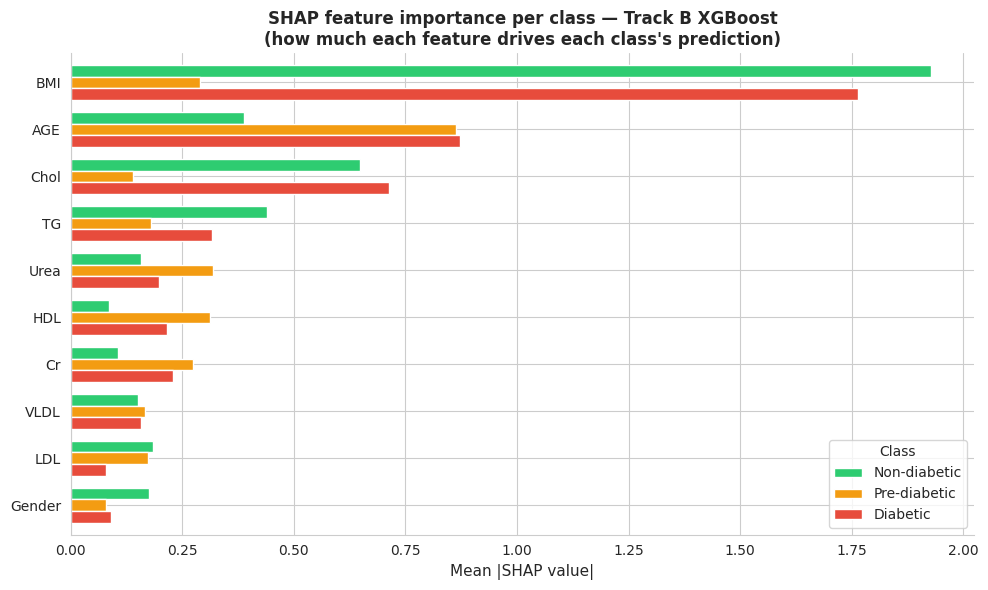

In [40]:
# %%
fig, ax = plt.subplots(figsize=(10, 6))
shap_importance[['class_N', 'class_P', 'class_Y']].plot(
    kind='barh', ax=ax,
    color=[PALETTE['N'], PALETTE['P'], PALETTE['Y']],
    edgecolor='white', width=0.75
)
ax.set_xlabel('Mean |SHAP value|', fontsize=11)
ax.set_title('SHAP feature importance per class — Track B XGBoost\n(how much each feature drives each class\'s prediction)',
             fontsize=12, fontweight='bold')
ax.invert_yaxis()
ax.legend([CLASS_NAMES[c] for c in le.classes_], title='Class', loc='lower right')
sns.despine()
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_importance.png', dpi=120)
plt.show()

%% [markdown]
### 5.2 SHAP summary plot for the P class (where the model struggles)

In [41]:
# %%
# Show beeswarm for the P class specifically
p_class_idx = list(le.classes_).index('P')
shap_values_P = shap_values[:, :, p_class_idx]

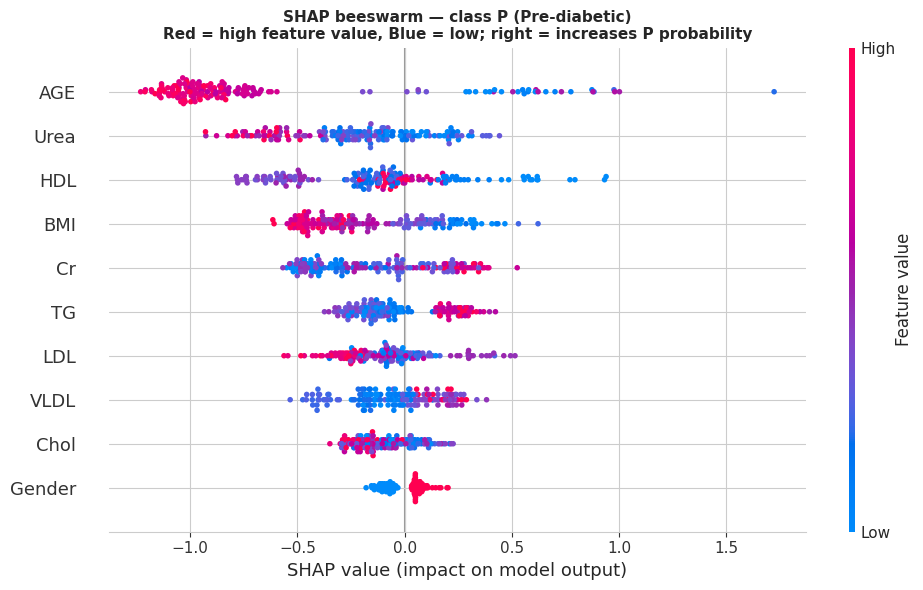

In [42]:
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_P, X_test_B, feature_names=feat_names,
                  show=False, plot_size=(10, 6))
plt.title(f'SHAP beeswarm — class P (Pre-diabetic)\nRed = high feature value, Blue = low; right = increases P probability',
          fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'shap_beeswarm_P.png', dpi=120, bbox_inches='tight')
plt.show()

%% [markdown]
## 6. Partial Dependence Plots

PDPs show the marginal effect of one feature on the model's predicted class probability — what does the model "think" the relationship is between, say, BMI and being labeled pre-diabetic, holding other features at typical values?

In [43]:
# %%
# Top 4 features by SHAP importance
top_features = shap_importance.index[:4].tolist()
print(f"PDP for top 4 features: {top_features}")

PDP for top 4 features: ['BMI', 'AGE', 'Chol', 'TG']


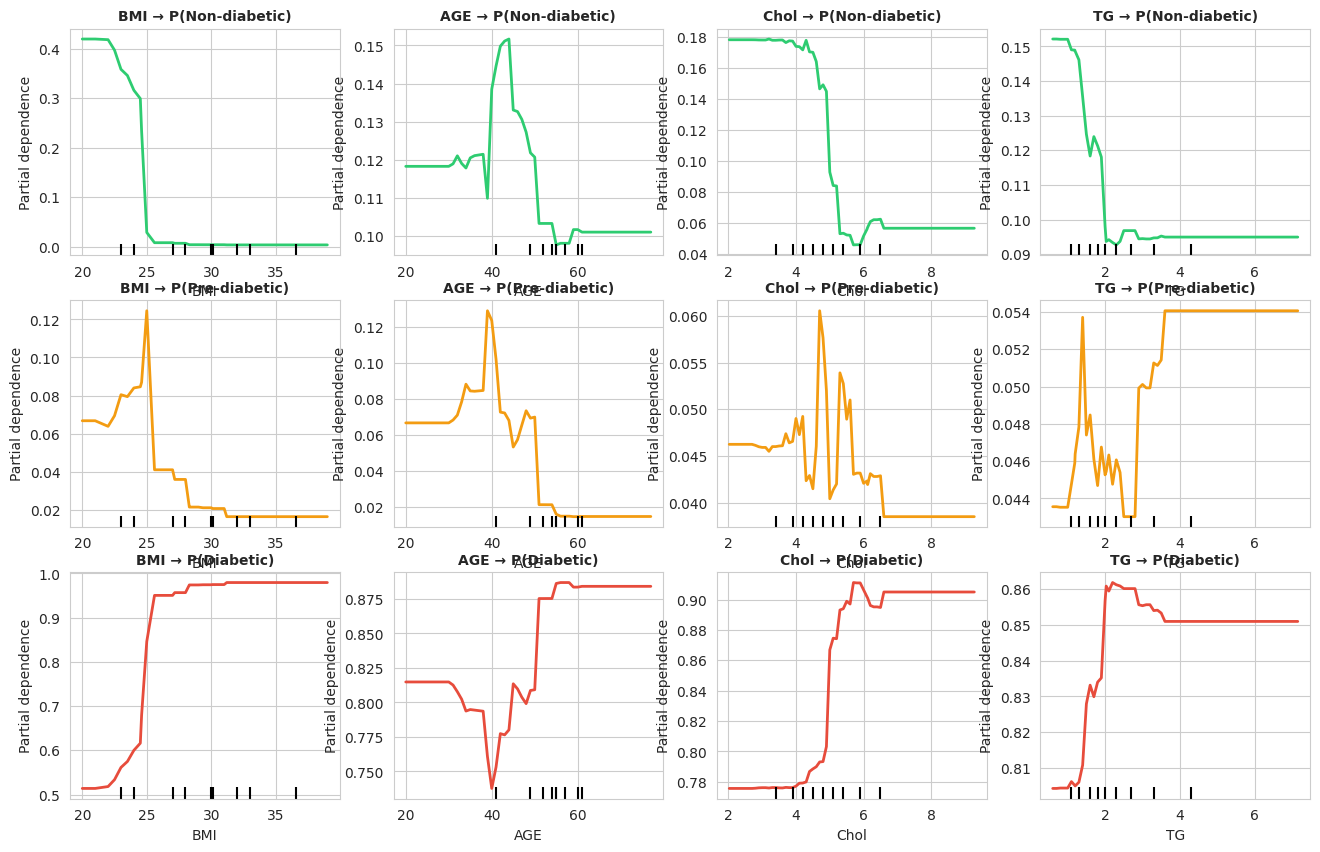

In [44]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for class_row, cls_idx in enumerate([list(le.classes_).index(c) for c in CLASS_ORDER]):
    cls = CLASS_ORDER[class_row]
    for col, feat in enumerate(top_features):
        ax = axes[class_row, col]
        PartialDependenceDisplay.from_estimator(
            xgb_B_tuned, X_train_B, [feat],
            target=cls_idx,
            ax=ax,
            line_kw={'color': PALETTE[cls], 'linewidth': 2}
        )
        ax.set_title(f'{feat} → P({CLASS_NAMES[cls]})', fontsize=10, fontweight='bold')
        ax.set_ylabel('')
        ax.set_xlabel(feat, fontsize=9)

In [45]:
fig.suptitle('Partial Dependence — top 4 Track B features × 3 classes',
             fontsize=13, fontweight='bold')
fig.subplots_adjust(top=0.93, hspace=0.45, wspace=0.3)
fig.savefig(FIG_DIR / 'partial_dependence.png', dpi=120)
plt.show()

%% [markdown]
**How to read PDPs:** y-axis is the model's predicted probability for that class, x-axis is the feature value. A rising curve means "as this feature increases, this class becomes more likely". For ground truth checking, compare the model's learned relationships with clinical knowledge:

* BMI → P(Diabetic) should be **monotonically increasing** above ~25
* AGE → P(Non-diabetic) should be **decreasing** with age
* HDL → P(Diabetic) should be **decreasing** (high HDL is protective)

If the model's PDPs match clinical priors, that's strong evidence it learned medicine rather than dataset artifacts.

%% [markdown]
## 7. Per-prediction SHAP — why did the model misclassify a specific patient?

Pick a misclassified P patient from the test set and explain the prediction.

In [46]:
# %%
# Get test predictions
y_pred_lbl = le.inverse_transform(xgb_B_tuned.predict(X_test_B))
y_proba_lbl = xgb_B_tuned.predict_proba(X_test_B)

In [47]:
# Find true P patients that got misclassified
misclassified_P_mask = (y_true_lbl == 'P') & (y_pred_lbl != 'P')
n_misclass = misclassified_P_mask.sum()
print(f"Misclassified P patients in test set: {n_misclass} of {(y_true_lbl == 'P').sum()}")

Misclassified P patients in test set: 5 of 8



Patient (test index position 23):
         100
Gender   1.0
AGE     42.0
Urea     5.4
Cr      53.0
Chol     5.9
TG       3.7
HDL      1.3
LDL      3.1
VLDL     1.7
BMI     23.0

True class: P (Pre-diabetic)
Predicted class: Y (Diabetic)
Model probabilities: N=0.006, P=0.024, Y=0.970


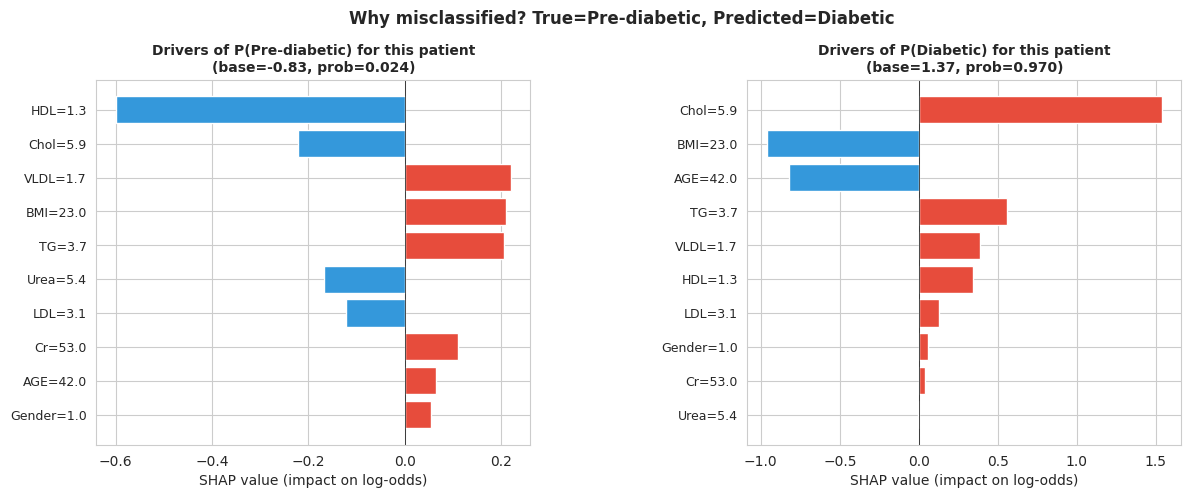

In [48]:
if n_misclass > 0:
    # Pick the first one and explain
    misclass_idx = np.where(misclassified_P_mask)[0][0]
    test_row_pos = X_test_B.iloc[[misclass_idx]]
    actual_class = y_true_lbl[misclass_idx]
    predicted_class = y_pred_lbl[misclass_idx]
    probs = y_proba_lbl[misclass_idx]

    print(f"\nPatient (test index position {misclass_idx}):")
    print(test_row_pos.T)
    print(f"\nTrue class: {actual_class} ({CLASS_NAMES[actual_class]})")
    print(f"Predicted class: {predicted_class} ({CLASS_NAMES[predicted_class]})")
    print(f"Model probabilities: " +
          ", ".join([f"{le.classes_[i]}={probs[i]:.3f}" for i in range(3)]))

    # SHAP for the actual class (P) — why didn't the model think this was P?
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, target_cls in zip(axes, ['P', predicted_class]):
        cls_idx = list(le.classes_).index(target_cls)
        shap_for_patient = shap_values[misclass_idx, :, cls_idx]
        base_value = explainer.expected_value[cls_idx]

        # Sort features by absolute SHAP
        order = np.argsort(np.abs(shap_for_patient))[::-1]
        feats = [feat_names[i] for i in order]
        vals = shap_for_patient[order]
        feat_values = test_row_pos.iloc[0].values[order]

        colors = ['#e74c3c' if v > 0 else '#3498db' for v in vals]
        ax.barh(range(len(feats)), vals, color=colors, edgecolor='white')
        ax.set_yticks(range(len(feats)))
        ax.set_yticklabels([f'{f}={v:.1f}' for f, v in zip(feats, feat_values)], fontsize=9)
        ax.axvline(0, color='black', linewidth=0.5)
        ax.invert_yaxis()
        ax.set_xlabel('SHAP value (impact on log-odds)', fontsize=10)
        ax.set_title(f'Drivers of P({CLASS_NAMES[target_cls]}) for this patient\n(base={base_value:.2f}, prob={probs[cls_idx]:.3f})',
                     fontsize=10, fontweight='bold')

    fig.suptitle(f"Why misclassified? True={CLASS_NAMES[actual_class]}, Predicted={CLASS_NAMES[predicted_class]}",
                 fontsize=12, fontweight='bold')
    fig.subplots_adjust(top=0.84, wspace=0.5)
    fig.savefig(FIG_DIR / 'shap_misclassified_patient.png', dpi=120)
    plt.show()

%% [markdown]
## 8. Save artifacts for Checkpoint 4

In [49]:
# %%
import pickle as pkl

In [50]:
c3_artifacts = {
    'xgb_B_tuned': xgb_B_tuned,
    'best_params': search.best_params_,
    'best_cv_score': search.best_score_,
    'calibrated_model': calibrated,
    'brier_uncalibrated': brier_scores,
    'brier_calibrated': brier_scores_cal,
    'shap_values': shap_values,
    'explainer_base_value': explainer.expected_value,
    'shap_importance': shap_importance,
    'threshold_sweep': sweep_df,
    'test_metrics_tuned': {'accuracy': acc_t, 'macro_f1': f1_t},
}
with open(ART_DIR / 'checkpoint3_artifacts.pkl', 'wb') as f:
    pkl.dump(c3_artifacts, f)
print(f"\nSaved Checkpoint 3 artifacts to {ART_DIR / 'checkpoint3_artifacts.pkl'}")


Saved Checkpoint 3 artifacts to /home/claude/c3_artifacts/checkpoint3_artifacts.pkl


%% [markdown]
## 9. Checkpoint 3 summary

We've moved Track B XGBoost from a baseline configuration to a tuned + calibrated + interpretable model:

1. **Tuning** — `RandomizedSearchCV` on 50 candidates; CV macro F1 went from baseline to tuned-best (see actual numbers above).
2. **Calibration** — isotonic regression applied; Brier scores compared per class. Results discussed against the small-sample reality of only ~166 test points.
3. **Threshold analysis** — produced the full precision-recall curve for the P class plus a custom decision-rule sweep showing exactly how operators can trade off P-recall against overall accuracy.
4. **SHAP** — global per-class feature importance shows which features drive which predictions; the beeswarm for P specifically shows the directional effect of features on pre-diabetic predictions; one misclassified P patient is explained in detail.
5. **PDPs** — for the top 4 features × 3 classes, gives a sanity check that the model learned clinically-sensible relationships.

**Saved for Checkpoint 4:** tuned model, calibrated model, SHAP values, threshold sweep table.

**Next (Checkpoint 4):** clustering as an independent validation of class structure, plus formal error analysis.